# 02 — Train DRL Algorithms on the NSE Portfolio Environment

This notebook trains **PPO, DQN, A2C, and REINFORCE** on all 67 NSE stocks.
Each algorithm runs 10 hyperparameter configurations.

---

## How Sharpe ratio is used in this notebook

Sharpe enters the training loop in two places:

### 1. `SharpeEvalCallback` (every `eval_freq` steps)
- Runs `n_eval_episodes` episodes on the **validation** environment
- Computes Sharpe **per episode** from each episode's value history
- Saves a model checkpoint **only if validation Sharpe improved**
- This replaces SB3's default `EvalCallback`, which saves by mean reward

### 2. Best-run selection (end of all 10 runs)
- Compares final validation Sharpe across all 10 runs
- Saves the winner as `models/{algo}/best_by_sharpe.zip`

---

## Why NOT use Sharpe as the step-level reward?

Sharpe = `mean(returns) / std(returns)` requires a **full return series**.
It cannot be computed at a single time step without the entire episode history.

Instead the reward function uses a **volatility penalty** as a Sharpe proxy:
```
reward(t) = portfolio_return - nse_costs - vol_penalty × rolling_std
```
Penalising `rolling_std` pushes the agent toward lower return variance,
which raises Sharpe at the episode level — without requiring a full series.


In [1]:
import os, sys, json, shutil, warnings
import numpy as np
import matplotlib.pyplot as plt
import gc

from stable_baselines3 import PPO, A2C, DQN
from stable_baselines3.common.monitor    import Monitor
from stable_baselines3.common.evaluation import evaluate_policy

sys.path.insert(0, "..")   # adjust if running from project root instead
warnings.filterwarnings("ignore")

from environment.nse_env   import NSEPortfolioEnv
from training.callbacks    import SharpeEvalCallback, RewardLogger
from evaluation.metrics    import mean_episode_sharpe, RF_DAILY

for d in ["models/ppo","models/dqn","models/a2c","models/reinforce","plots"]:
    os.makedirs(d, exist_ok=True)

# Quick sanity check
_env = NSEPortfolioEnv(period="train")
print(f"Observation shape : {_env.observation_space.shape}  <- expect (536,)")
print(f"Action space      : {_env.action_space.n}           <- expect 136")
print(f"Tickers           : {len(_env.tickers)} stocks")
_env.close()
print("\nImports and environment OK.")

Observation shape : (536,)  <- expect (536,)
Action space      : 136           <- expect 136
Tickers           : 67 stocks

Imports and environment OK.


In [2]:
import sys
sys.setrecursionlimit(10000)

# Reconfigure rich before SB3 imports it
try:
    from rich import reconfigure
    reconfigure(force_terminal=False, force_jupyter=False)
except ImportError:
    pass

## Set training duration

| TIMESTEPS | Time per run | Total (40 runs) |
|-----------|-------------|-----------------|
| 5,000     | ~30 sec     | ~20 min — sanity check |
| 200,000   | ~20 min     | ~13 hours |
| 500,000   | ~40 min     | ~27 hours |

Start with `5_000` to verify nothing crashes, then increase.


In [3]:
import inspect
from environment.nse_env import NSEPortfolioEnv

# Print the actual _obs method that is currently loaded in memory
print(inspect.getsource(NSEPortfolioEnv._obs))

    def _obs(self) -> np.ndarray:
        t  = min(self.t, self.T - 1)
        av = self.avail[t]
        r1  = self._r1[t]  * av
        r5  = self._r5[t]  * av
        r20 = self._r20[t] * av
        r60 = self._r60[t] * av
        v20 = self._v20[t] * av
        cs  = self._cs[t]  * av
        am  = np.clip(self._am[t] / (self._am95 + 1e-12), 0, 5) * av
        obs = np.concatenate([r1, r5, r20, r60, v20, cs, am, self.weights]).astype(np.float32)
        obs = np.nan_to_num(obs, nan=0.0, posinf=0.0, neginf=0.0)
        return np.clip(obs, -10.0, 10.0)



In [4]:
import numpy as np
from environment.nse_env import NSEPortfolioEnv

env = NSEPortfolioEnv(period="train")
obs, info = env.reset(seed=42)

print("=== Reset check ===")
print(f"obs NaN count : {np.isnan(obs).sum()}")
print(f"obs Inf count : {np.isinf(obs).sum()}")
print(f"obs min/max   : {obs.min():.4f} / {obs.max():.4f}")

nan_count = 0
inf_count = 0
rewards   = []

for step in range(200):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    
    if np.isnan(obs).any():
        nan_count += 1
        if nan_count <= 3:
            print(f"\nStep {step}: NaN in obs at indices {np.where(np.isnan(obs))[0][:5]}")
    
    if np.isinf(obs).any():
        inf_count += 1
        
    if np.isnan(reward) or np.isinf(reward):
        print(f"Step {step}: Bad reward = {reward}")
    
    rewards.append(reward)
    
    if terminated or truncated:
        obs, info = env.reset()

env.close()

print(f"\n=== After 200 steps ===")
print(f"NaN obs steps   : {nan_count}")
print(f"Inf obs steps   : {inf_count}")
print(f"Reward NaN count: {sum(np.isnan(r) for r in rewards)}")
print(f"Reward range    : {min(rewards):.4f} to {max(rewards):.4f}")
print(f"Portfolio value : {info['portfolio_value']}")

=== Reset check ===
obs NaN count : 0
obs Inf count : 0
obs min/max   : -0.2442 / 1.6725

=== After 200 steps ===
NaN obs steps   : 0
Inf obs steps   : 0
Reward NaN count: 0
Reward range    : -0.0295 to 0.0198
Portfolio value : 67137.19


In [5]:
import numpy as np
from environment.nse_env import NSEPortfolioEnv

env = NSEPortfolioEnv(period="train")
obs, info = env.reset(seed=42)

print("After reset:")
print(f"  portfolio_val : {env.portfolio_val}")
print(f"  peak_val      : {env.peak_val}")
print(f"  weights sum   : {env.weights.sum():.6f}")
print(f"  weights NaN   : {np.isnan(env.weights).sum()}")
print(f"  prices[t] NaN : {np.isnan(env.prices[env.t]).sum()}")
print(f"  prices[t] sample: {env.prices[env.t][:5]}")

# Take one step manually and inspect every variable
action = 135  # HOLD — no cost, no trade
obs, reward, term, trunc, info = env.step(action)

print(f"\nAfter step 0 (HOLD):")
print(f"  reward        : {reward}")
print(f"  portfolio_val : {env.portfolio_val}")
print(f"  portfolio_val NaN: {np.isnan(env.portfolio_val)}")

# Check what prices look like at t and t-1
tc = min(env.t, env.T - 1)
tp = env.t - 1
print(f"\n  prices[tc] NaN count : {np.isnan(env.prices[tc]).sum()}")
print(f"  prices[tp] NaN count : {np.isnan(env.prices[tp]).sum()}")
print(f"  prices[tc][:5]       : {env.prices[tc][:5]}")
print(f"  prices[tp][:5]       : {env.prices[tp][:5]}")

# Compute price return manually
ret = ((env.prices[tc] - env.prices[tp]) / (env.prices[tp] + 1e-8)) * env.avail[tc]
print(f"\n  ret NaN count : {np.isnan(ret).sum()}")
print(f"  ret[:5]       : {ret[:5]}")

# Compute portfolio return manually
pr = float(np.dot(env.weights, ret))
print(f"  weights[:5]   : {env.weights[:5]}")
print(f"  portfolio_ret : {pr}")

# Check reward history
print(f"\n  reward_hist length : {len(env.reward_hist)}")
print(f"  vol_penalty        : {env._vol_penalty}")
vol = float(np.std(env.reward_hist[-20:])) if len(env.reward_hist) >= 20 else 0.0
print(f"  rolling vol        : {vol}")

env.close()

After reset:
  portfolio_val : 100000.0
  peak_val      : 100000.0
  weights sum   : 1.000000
  weights NaN   : 0
  prices[t] NaN : 3
  prices[t] sample: [ 15.7  36.4 177.  260.    nan]

After step 0 (HOLD):
  reward        : -0.0028556776233017445
  portfolio_val : 99714.43223766983
  portfolio_val NaN: False

  prices[tc] NaN count : 3
  prices[tp] NaN count : 3
  prices[tc][:5]       : [ 15.7  36.4 177.  258.    nan]
  prices[tp][:5]       : [ 15.7  36.4 177.  260.    nan]

  ret NaN count : 3
  ret[:5]       : [ 0.          0.          0.         -0.00769231         nan]
  weights[:5]   : [0.         0.02439024 0.02439024 0.02439024 0.        ]
  portfolio_ret : nan

  reward_hist length : 1
  vol_penalty        : 0.03755513759008209
  rolling vol        : 0.0


In [6]:
TIMESTEPS = 5000000

In [7]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU name:      ", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")
print("VRAM:          ", torch.cuda.get_device_properties(0).total_memory / 1e9, "GB")

CUDA available: True
GPU name:       NVIDIA GeForce RTX 3060 Laptop GPU
VRAM:           6.441926656 GB


In [8]:
import torch

print("PyTorch version :", torch.__version__)
print("CUDA available  :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name        :", torch.cuda.get_device_name(0))
    print("VRAM            :", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "GB")
    print()
    print("GPU is ready for training.")
else:
    print()
    print("GPU not detected. Something went wrong with the install.")
    print("Try: pip install torch==2.2.2+cu121 --index-url https://download.pytorch.org/whl/cu121")

PyTorch version : 2.2.2+cu121
CUDA available  : True
GPU name        : NVIDIA GeForce RTX 3060 Laptop GPU
VRAM            : 6.4 GB

GPU is ready for training.


In [9]:
import torch

if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU not detected. Fix before training:\n"
        "  pip uninstall torch -y\n"
        "  pip install torch==2.2.2 --index-url https://download.pytorch.org/whl/cu121"
    )

print(f"GPU : {torch.cuda.get_device_name(0)}")
print(f"VRAM: {round(torch.cuda.get_device_properties(0).total_memory/1e9,1)} GB")
print(f"Ready. Training will run on GPU automatically.")

GPU : NVIDIA GeForce RTX 3060 Laptop GPU
VRAM: 6.4 GB
Ready. Training will run on GPU automatically.


## Hyperparameter grids

10 configurations per algorithm. Each changes one or two parameters
from a sensible baseline. After all 10 runs, the best is selected
by **validation Sharpe ratio**.


In [21]:
NET = {"net_arch": [256, 256]}   # MLP: input(536) -> 256 -> 256 -> output

PPO_CONFIGS = [
    {"run":1,  "lr":3e-4, "gamma":0.99,"n":2048,"ent":0.01, "clip":0.20,"ep":10,"gae":0.95,"note":"Baseline"},
    {"run":2,  "lr":1e-4, "gamma":0.99,"n":2048,"ent":0.01, "clip":0.20,"ep":10,"gae":0.95,"note":"Low LR"},
    {"run":3,  "lr":1e-3, "gamma":0.99,"n":2048,"ent":0.01, "clip":0.20,"ep":10,"gae":0.95,"note":"High LR"},
    {"run":4,  "lr":3e-4, "gamma":0.95,"n":2048,"ent":0.01, "clip":0.20,"ep":10,"gae":0.95,"note":"Low gamma"},
    {"run":5,  "lr":3e-4, "gamma":0.99,"n":4096,"ent":0.01, "clip":0.20,"ep":10,"gae":0.95,"note":"Long rollout"},
    {"run":6,  "lr":3e-4, "gamma":0.99,"n":1024,"ent":0.05, "clip":0.20,"ep":5, "gae":0.90,"note":"Short rollout"},
    {"run":7,  "lr":3e-4, "gamma":0.99,"n":2048,"ent":0.01, "clip":0.10,"ep":10,"gae":0.95,"note":"Tight clip"},
    {"run":8,  "lr":3e-4, "gamma":0.99,"n":2048,"ent":0.02, "clip":0.30,"ep":10,"gae":0.98,"note":"Loose clip"},
    {"run":9,  "lr":3e-4, "gamma":0.97,"n":2048,"ent":0.005,"clip":0.15,"ep":10,"gae":0.92,"note":"Exploit"},
    {"run":10, "lr":1e-3, "gamma":0.99,"n":512, "ent":0.02, "clip":0.20,"ep":4, "gae":0.95,"note":"Aggressive"},
]

DQN_CONFIGS = [
    {"run":1,  "lr":1e-3,"gamma":0.99,"buf":50000, "batch":64, "eps":0.05,"tgt":500, "note":"Baseline"},
    {"run":2,  "lr":5e-4,"gamma":0.99,"buf":50000, "batch":64, "eps":0.05,"tgt":500, "note":"Low LR"},
    {"run":3,  "lr":1e-4,"gamma":0.99,"buf":50000, "batch":64, "eps":0.05,"tgt":500, "note":"VLow LR"},
    {"run":4,  "lr":1e-3,"gamma":0.95,"buf":50000, "batch":64, "eps":0.05,"tgt":500, "note":"Low gamma"},
    {"run":5,  "lr":1e-3,"gamma":0.99,"buf":10000, "batch":32, "eps":0.10,"tgt":200, "note":"Small buf"},
    {"run":6,  "lr":1e-3,"gamma":0.99,"buf":100000,"batch":128,"eps":0.02,"tgt":1000,"note":"Large buf"},
    {"run":7,  "lr":1e-3,"gamma":0.99,"buf":50000, "batch":64, "eps":0.20,"tgt":500, "note":"High eps"},
    {"run":8,  "lr":1e-3,"gamma":0.99,"buf":50000, "batch":256,"eps":0.01,"tgt":500, "note":"Large batch"},
    {"run":9,  "lr":5e-4,"gamma":0.97,"buf":20000, "batch":64, "eps":0.05,"tgt":300, "note":"Mid"},
    {"run":10, "lr":1e-3,"gamma":0.90,"buf":50000, "batch":64, "eps":0.05,"tgt":500, "note":"Myopic"},
]

A2C_CONFIGS = [
    {"run":1,  "lr":0.0007, "gamma":0.99, "n":126, "ent":0.01,  "vf":0.5, "gae":0.95, "note":"Baseline"},
    {"run":2,  "lr":0.0003, "gamma":0.99, "n":126, "ent":0.01,  "vf":0.5, "gae":0.95, "note":"Low LR"},
    {"run":3,  "lr":0.001,  "gamma":0.99, "n":126, "ent":0.01,  "vf":0.5, "gae":0.95, "note":"High LR"},
    {"run":4,  "lr":0.0007, "gamma":0.95, "n":126, "ent":0.01,  "vf":0.5, "gae":0.95, "note":"Low gamma"},
    {"run":5,  "lr":0.0007, "gamma":0.99, "n":252, "ent":0.01,  "vf":0.5, "gae":0.95, "note":"Long rollout"},
    {"run":6,  "lr":0.0007, "gamma":0.99, "n":63,  "ent":0.05,  "vf":0.5, "gae":0.9,  "note":"High ent"},
    {"run":7,  "lr":0.0007, "gamma":0.99, "n":126, "ent":0.005, "vf":0.5, "gae":0.95, "note":"Low ent"},
    {"run":8,  "lr":0.0007, "gamma":0.99, "n":126, "ent":0.01,  "vf":1.0, "gae":0.95, "note":"High vf"},
    {"run":9,  "lr":0.0003, "gamma":0.97, "n":126, "ent":0.005, "vf":0.5, "gae":0.92, "note":"Exploit"},
    {"run":10, "lr":0.001,  "gamma":0.99, "n":252, "ent":0.02,  "vf":0.5, "gae":0.95, "note":"Aggressive"},
]

REINFORCE_CONFIGS = [
    {"run":1,  "lr":1e-3, "gamma":0.99, "n":2016, "ent":0.00, "clip":0.2, "ep":10, "gae":0.95, "note":"Baseline"},
    {"run":2,  "lr":5e-4, "gamma":0.99, "n":2016, "ent":0.00, "clip":0.2, "ep":10, "gae":0.95, "note":"Low LR"},
    {"run":3,  "lr":2e-3, "gamma":0.99, "n":2016, "ent":0.00, "clip":0.2, "ep":10, "gae":0.95, "note":"High LR"},
    {"run":4,  "lr":1e-3, "gamma":0.95, "n":2016, "ent":0.00, "clip":0.2, "ep":10, "gae":0.95, "note":"Low gamma"},
    {"run":5,  "lr":1e-3, "gamma":0.90, "n":2016, "ent":0.00, "clip":0.2, "ep":10, "gae":0.95, "note":"VLow gamma"},
    {"run":6,  "lr":1e-3, "gamma":0.99, "n":1008, "ent":0.00, "clip":0.2, "ep":10, "gae":0.95, "note":"Short traj"},
    {"run":7,  "lr":1e-3, "gamma":0.99, "n":5040, "ent":0.00, "clip":0.2, "ep":10, "gae":0.95, "note":"Long traj"},
    {"run":8,  "lr":1e-3, "gamma":0.99, "n":2016, "ent":0.01, "clip":0.2, "ep":10, "gae":0.95, "note":"Sm entropy"},
    {"run":9,  "lr":3e-4, "gamma":0.99, "n":1008, "ent":0.00, "clip":0.2, "ep":10, "gae":0.95, "note":"LR+short"},
    {"run":10, "lr":1e-3, "gamma":0.97, "n":2016, "ent":0.02, "clip":0.2, "ep":10, "gae":0.95, "note":"Mid+ent"},
]

print(f"Configs ready: 10 runs x 4 algorithms = 40 total training jobs.")
print(f"Each run: {TIMESTEPS:,} timesteps.")

Configs ready: 10 runs x 4 algorithms = 40 total training jobs.
Each run: 5,000,000 timesteps.


## Core training function

`SharpeEvalCallback` is attached here. It fires every `eval_freq` steps,
runs episodes on the validation environment, computes **per-episode Sharpe**,
and saves a checkpoint only when Sharpe improves.

At the end of the run, `compute_val_sharpe()` gives a clean 10-episode
Sharpe for the final run-selection comparison.


In [15]:
import os
from stable_baselines3.common.vec_env import SubprocVecEnv, DummyVecEnv

# Number of parallel environments
# 4 is a good starting point for your 6GB RTX 3060
# If you get crashes, reduce to 2
N_ENVS = 4

def make_env_fn(period="train"):
    """Returns a callable that creates one environment instance."""
    def _init():
        return Monitor(NSEPortfolioEnv(period=period))
    return _init


def make_vec_env(period="train", n_envs=N_ENVS):
    """
    Creates N parallel environments.
    
    SubprocVecEnv: each environment runs in a separate process
                   faster but can have issues on Windows
    DummyVecEnv:   all environments run in the same process
                   safer on Windows, slightly less speedup
    """
    env_fns = [make_env_fn(period) for _ in range(n_envs)]
    try:
        env = SubprocVecEnv(env_fns, start_method="spawn")
        print(f"  Using SubprocVecEnv with {n_envs} parallel environments")
    except Exception as e:
        print(f"  SubprocVecEnv failed ({e}), falling back to DummyVecEnv")
        env = DummyVecEnv(env_fns)
    return env


def make_env(period="train"):
    """Single environment — used for validation and evaluation."""
    return Monitor(NSEPortfolioEnv(period=period))


def compute_val_sharpe(model, n=10):
    """Run n episodes on val set. Return mean per-episode Sharpe."""
    env = NSEPortfolioEnv(period="val", domain_randomise=False)
    value_hists = []
    for _ in range(n):
        obs, _ = env.reset()
        done   = False
        values = [env.INITIAL_CAPITAL]
        while not done:
            act, _ = model.predict(obs, deterministic=True)
            obs, _, t, tr, info = env.step(int(act))
            done = t or tr
            values.append(info["portfolio_value"])
        value_hists.append(values)
    env.close()
    return mean_episode_sharpe(value_hists, RF_DAILY)["mean"]


def train_one(algo, cfg, model_cls, kwargs):
    save_path = f"models/{algo}/run_{cfg['run']}_best"

    # Single environment — hyperparameters were tuned for this
    # GPU still used for the policy update step
    train_env = make_env("train")

    rl  = RewardLogger()
    scb = SharpeEvalCallback(
        val_env_fn      = lambda: make_env("val"),
        eval_freq       = max(TIMESTEPS // 10, 2000),
        save_path       = save_path,
        n_eval_episodes = 5,
        patience        = 5,
        verbose         = 1,
    )

    model = model_cls("MlpPolicy", train_env, policy_kwargs=NET, verbose=0, **kwargs)

    # Confirm GPU
    device = next(model.policy.parameters()).device
    print(f"  Device: {device}")

    model.learn(
        total_timesteps = TIMESTEPS,
        callback        = [rl, scb],
        progress_bar    = True,
    )

    model.save(f"models/{algo}/run_{cfg['run']}_final")
    train_env.close()

    val_sharpe = compute_val_sharpe(model, n=10)

    return {
        **cfg,
        "val_sharpe":       round(scb.best_sharpe, 5),
        "best_ckpt_sharpe": round(scb.best_sharpe, 5),
        "final_sharpe":     round(val_sharpe,       5),
        "stopped_early":    scb.stopped_early,
        "episode_rewards":  rl.episode_rewards,
        "sharpe_history":   scb.sharpe_history,
        "sharpe_steps":     scb.eval_steps,
    }


print(f"Training functions ready. N_ENVS={N_ENVS}")

Training functions ready. N_ENVS=4


## Train PPO

After all 10 runs, the run with the highest `val_sharpe` is copied to
`models/ppo/best_by_sharpe.zip`. This is what the backtest notebook loads.


In [11]:
ppo_results = []
print(f"{'='*60}")
print(f"PPO — 10 runs x {TIMESTEPS:,} timesteps")
print(f"Obs: 536  Actions: 136")
print(f"{'='*60}")

for cfg in PPO_CONFIGS:
    print(f"\nRun {cfg['run']}/10 — {cfg['note']}")
    r = train_one("ppo", cfg, PPO, {
        "learning_rate": cfg["lr"],
        "gamma":         cfg["gamma"],
        "n_steps":       cfg["n"],
        "ent_coef":      cfg["ent"],
        "clip_range":    cfg["clip"],
        "n_epochs":      cfg["ep"],
        "gae_lambda":    cfg["gae"],
    })
    ppo_results.append(r)
    print(f"  Final val Sharpe : {r['val_sharpe']:>+.4f}")
    print(f"  Best ckpt Sharpe : {r['best_ckpt_sharpe']:>+.4f}")

# Select best run by VALIDATION SHARPE (not mean reward)
best_ppo = max(ppo_results, key=lambda x: x["val_sharpe"])
src = f"models/ppo/run_{best_ppo['run']}_best.zip"
if os.path.exists(src):
    shutil.copy(src, "models/ppo/best_by_sharpe.zip")
    print(f"\nBest PPO saved : models/ppo/best_by_sharpe.zip")

print(f"Best run       : Run {best_ppo['run']} ({best_ppo['note']})")
print(f"Val Sharpe     : {best_ppo['val_sharpe']:>+.4f}")

clean = [{k:v for k,v in r.items() if k not in ("episode_rewards","sharpe_history","sharpe_steps")}
         for r in ppo_results]
with open("models/ppo/ppo_results.json", "w") as f:
    json.dump(clean, f, indent=2)

PPO — 10 runs x 5,000,000 timesteps
Obs: 536  Actions: 136

Run 1/10 — Baseline
  Device: cuda:0


[Step  500,000]  Val Sharpe:  -2.5000  (best:     -inf) <- NEW BEST

[Step 1,000,000]  Val Sharpe:  -2.8444  (best:  -2.5000) (no improve 1/5)

[Step 1,500,000]  Val Sharpe:  -2.3087  (best:  -2.5000) <- NEW BEST

[Step 2,000,000]  Val Sharpe:  -1.8098  (best:  -2.3087) <- NEW BEST

...

[Step 2,500,000]  Val Sharpe:  -1.3157  (best:  -1.0166) (no improve 3/5)

[Step 3,000,000]  Val Sharpe:  -1.3205  (best:  -1.0166) (no improve 4/5)

[Step 3,500,000]  Val Sharpe:  -2.6005  (best:  -1.0166) (no improve 5/5)

[Early Stop] No Sharpe improvement for 5 consecutive evaluations.
  Best Sharpe was -1.0166 at step 1,000,000.
  Stopping training now to avoid policy degradation.

  Final val Sharpe : -1.0167
  Best ckpt Sharpe : -1.0167

Best PPO saved : models/ppo/best_by_sharpe.zip
Best run       : Run 9 (Exploit)
Val Sharpe     : -0.6438


## Train DQN

In [ ]:
dqn_results = []
print(f"{'='*60}\nDQN — 10 runs\n{'='*60}")

for cfg in DQN_CONFIGS:
    print(f"\nRun {cfg['run']}/10 — {cfg['note']}")
    r = train_one("dqn", cfg, DQN, {
        "learning_rate":          cfg["lr"],
        "gamma":                  cfg["gamma"],
        "buffer_size":            cfg["buf"],
        "batch_size":             cfg["batch"],
        "exploration_final_eps":  cfg["eps"],
        "target_update_interval": cfg["tgt"],
    })
    dqn_results.append(r)
    print(f"  Val Sharpe: {r['val_sharpe']:>+.4f}")

best_dqn = max(dqn_results, key=lambda x: x["val_sharpe"])
src = f"models/dqn/run_{best_dqn['run']}_best.zip"
if os.path.exists(src):
    shutil.copy(src, "models/dqn/best_by_sharpe.zip")
print(f"\nBest DQN: Run {best_dqn['run']} ({best_dqn['note']})  Val Sharpe: {best_dqn['val_sharpe']:>+.4f}")

clean = [{k:v for k,v in r.items() if k not in ("episode_rewards","sharpe_history","sharpe_steps")}
         for r in dqn_results]
with open("models/dqn/dqn_results.json", "w") as f:
    json.dump(clean, f, indent=2)

DQN — 10 runs

Run 1/10 — Baseline
  Device: cuda:0


[Step  500,000]  Val Sharpe:  -1.6133  (best:     -inf) <- NEW BEST

[Step 1,000,000]  Val Sharpe:  -2.3146  (best:  -1.6133) (no improve 1/5)

[Step 1,500,000]  Val Sharpe:  -2.6318  (best:  -1.6133) (no improve 2/5)

[Step 2,000,000]  Val Sharpe:  -3.4494  (best:  -1.6133) (no improve 3/5)

...

[Step 4,000,000]  Val Sharpe:  -1.9594  (best:  -0.8583) (no improve 2/5)

[Step 4,500,000]  Val Sharpe:  -3.3589  (best:  -0.8583) (no improve 3/5)

[Step 5,000,000]  Val Sharpe:  -3.8133  (best:  -0.8583) (no improve 4/5)

  Val Sharpe: -0.8583

Best DQN: Run 9 (Mid)  Val Sharpe: -0.7621


: 

## Train A2C

In [16]:
# A2C 
a2c_results = []
os.makedirs("models/a2c", exist_ok=True)
print(f"{'='*60}\nA2C — 10 runs\n{'='*60}")

for cfg in A2C_CONFIGS:
    print(f"\nRun {cfg['run']}/10 — {cfg['note']}")
    r = train_one("a2c", cfg, A2C, {
        "learning_rate": cfg["lr"],
        "gamma":         cfg["gamma"],
        "n_steps":       cfg["n"],
        "ent_coef":      cfg["ent"],
        "vf_coef":       cfg["vf"],
        "gae_lambda":    cfg["gae"],
    })
    a2c_results.append(r)
    print(f"  Val Sharpe: {r['val_sharpe']:>+.4f}")

    # Save after every run
    clean = [{k: v for k, v in x.items()
              if k not in ("episode_rewards", "sharpe_history", "sharpe_steps")}
             for x in a2c_results]
    with open("models/a2c/a2c_results_partial.json", "w") as f:
        json.dump(clean, f, indent=2)
    gc.collect()

best_a2c = max(a2c_results, key=lambda x: x["val_sharpe"])
src = f"models/a2c/run_{best_a2c['run']}_best.zip"
if os.path.exists(src):
    shutil.copy(src, "models/a2c/best_by_sharpe.zip")
print(f"\nBest A2C: Run {best_a2c['run']} ({best_a2c['note']})  "
      f"Val Sharpe: {best_a2c['val_sharpe']:>+.4f}")

with open("models/a2c/a2c_results_full.json", "w") as f:
    json.dump(a2c_results, f, indent=2)
with open("models/a2c/a2c_results.json", "w") as f:
    json.dump(clean, f, indent=2)
print("A2C complete — results saved")

A2C — 10 runs

Run 1/10 — Baseline
  Device: cuda:0
  [Step  500,000]  Val Sharpe:  -1.3376  (best:     -inf) <- NEW BEST
  [Step 1,000,000]  Val Sharpe:  -3.4271  (best:  -1.3376) (no improve 1/5)
  [Step 1,500,000]  Val Sharpe:  -1.6927  (best:  -1.3376) (no improve 2/5)
  [Step 2,000,000]  Val Sharpe:  -1.7442  (best:  -1.3376) (no improve 3/5)
  [Step 2,500,000]  Val Sharpe:  -1.3190  (best:  -1.3376) <- NEW BEST
  [Step 3,000,000]  Val Sharpe:  -2.1916  (best:  -1.3190) (no improve 1/5)
  [Step 3,500,000]  Val Sharpe:  -1.8481  (best:  -1.3190) (no improve 2/5)
  [Step 4,000,000]  Val Sharpe:  -1.1062  (best:  -1.3190) <- NEW BEST
  [Step 4,500,000]  Val Sharpe:  -2.8176  (best:  -1.1062) (no improve 1/5)
  [Step 5,000,000]  Val Sharpe:  -2.4970  (best:  -1.1062) (no improve 2/5)
 100% -------------------- 5,000,058/5,000,000 [ 3:01:55 < 0:00:00 , 460 it/s ]

  Val Sharpe: -1.1061

Run 2/10 — Low LR
  Device: cuda:0
  [Step  500,000]  Val Sharpe:  -2.7562  (best:     -inf) <- NEW 

## Train REINFORCE

REINFORCE = PPO with `clip_range=1.0` and `n_epochs=1`.
Removing the clipping and the multiple update epochs leaves only the
original REINFORCE policy gradient update, making it the baseline
lower-bound reference for the other algorithms.


In [ ]:
# REINFORCE (PPO with no value function) 
reinforce_results = []
os.makedirs("models/reinforce", exist_ok=True)
print(f"{'='*60}\nREINFORCE — 10 runs\n{'='*60}")

for cfg in REINFORCE_CONFIGS:
    print(f"\nRun {cfg['run']}/10 — {cfg['note']}")
    r = train_one("reinforce", cfg, PPO, {
        "learning_rate": cfg["lr"],
        "gamma":         cfg["gamma"],
        "n_steps":       cfg["n"],
        "ent_coef":      cfg["ent"],
        "clip_range":    cfg["clip"],
        "n_epochs":      cfg["ep"],
        "gae_lambda":    cfg["gae"],
        "vf_coef":       0.0,   # disables value function — makes it REINFORCE
    })
    reinforce_results.append(r)
    print(f"  Val Sharpe: {r['val_sharpe']:>+.4f}")

    clean = [{k: v for k, v in x.items()
              if k not in ("episode_rewards", "sharpe_history", "sharpe_steps")}
             for x in reinforce_results]
    with open("models/reinforce/reinforce_results_partial.json", "w") as f:
        json.dump(clean, f, indent=2)
    gc.collect()

best_rf = max(reinforce_results, key=lambda x: x["val_sharpe"])
src = f"models/reinforce/run_{best_rf['run']}_best.zip"
if os.path.exists(src):
    shutil.copy(src, "models/reinforce/best_by_sharpe.zip")
print(f"\nBest REINFORCE: Run {best_rf['run']} ({best_rf['note']})  "
      f"Val Sharpe: {best_rf['val_sharpe']:>+.4f}")

with open("models/reinforce/reinforce_results_full.json", "w") as f:
    json.dump(reinforce_results, f, indent=2)
with open("models/reinforce/reinforce_results.json", "w") as f:
    json.dump(clean, f, indent=2)
print("REINFORCE complete — results saved")

REINFORCE — 10 runs

Run 1/10 — Baseline
  Device: cuda:0
  [Step  500,000]  Val Sharpe:  -1.9659  (best:     -inf) <- NEW BEST
  [Step 1,000,000]  Val Sharpe:  -2.1540  (best:  -1.9659) (no improve 1/5)
  [Step 1,500,000]  Val Sharpe:  -1.6191  (best:  -1.9659) <- NEW BEST
  [Step 2,000,000]  Val Sharpe:  -1.6087  (best:  -1.6191) <- NEW BEST
  [Step 2,500,000]  Val Sharpe:  -1.6201  (best:  -1.6087) (no improve 1/5)
  [Step 3,000,000]  Val Sharpe:  -1.1661  (best:  -1.6087) <- NEW BEST
  [Step 3,500,000]  Val Sharpe:  -0.6518  (best:  -1.1661) <- NEW BEST
  [Step 4,000,000]  Val Sharpe:  -2.1006  (best:  -0.6518) (no improve 1/5)
  [Step 4,500,000]  Val Sharpe:  -2.7807  (best:  -0.6518) (no improve 2/5)
  [Step 5,000,000]  Val Sharpe:  -1.5364  (best:  -0.6518) (no improve 3/5)
 100% -------------------- 5,001,696/5,000,000 [ 4:16:04 < 0:00:00 , 332 it/s ]

  Val Sharpe: -0.6518
   1%                  67,788/5,000,000 [ 1 day, 7:54:44 < 6:27:44 , 212 it/s ]
   0%                    

## Algorithm comparison by validation Sharpe

This is the primary comparison table from the proposal.
Best run per algorithm, selected by validation Sharpe.


In [ ]:
all_bests = [
    ("PPO",       best_ppo),
    ("DQN",       best_dqn),
    ("A2C",       best_a2c),
    ("REINFORCE", best_rf),
]

print(f"\n{'Algorithm':<12} {'Best Run':>8}  {'Val Sharpe':>12}  Config")
print("─" * 54)
for algo, best in all_bests:
    print(f"  {algo:<10} {best['run']:>8}   {best['val_sharpe']:>+10.4f}   {best['note']}")

winner = max(all_bests, key=lambda x: x[1]["val_sharpe"])
print(f"\nBest overall: {winner[0]}  (val Sharpe = {winner[1]['val_sharpe']:>+.4f})")


Algorithm    Best Run    Val Sharpe  Config
──────────────────────────────────────────────────────
  PPO               8      -1.1271   Loose clip
  DQN               4      -1.2167   Low gamma
  A2C               9      -0.4758   Mid
  REINFORCE         7      -1.0846   Long traj

Best overall: A2C  (val Sharpe = -0.4758)


## Plot 1 — Validation Sharpe progression during training

Each line is one of the 10 runs. The y-axis is the validation Sharpe
recorded by `SharpeEvalCallback` at each evaluation checkpoint.

**What to look for:**
- Rising lines: the agent is improving in risk-adjusted terms
- Flat lines: the agent has stopped learning (try more timesteps)
- Lines all clustering below 0: the 4.16% NSE cost is dominating —
  the agent has not learned to trade infrequently enough

The red dashed line at 0 is the T-bill breakeven (13% annual).


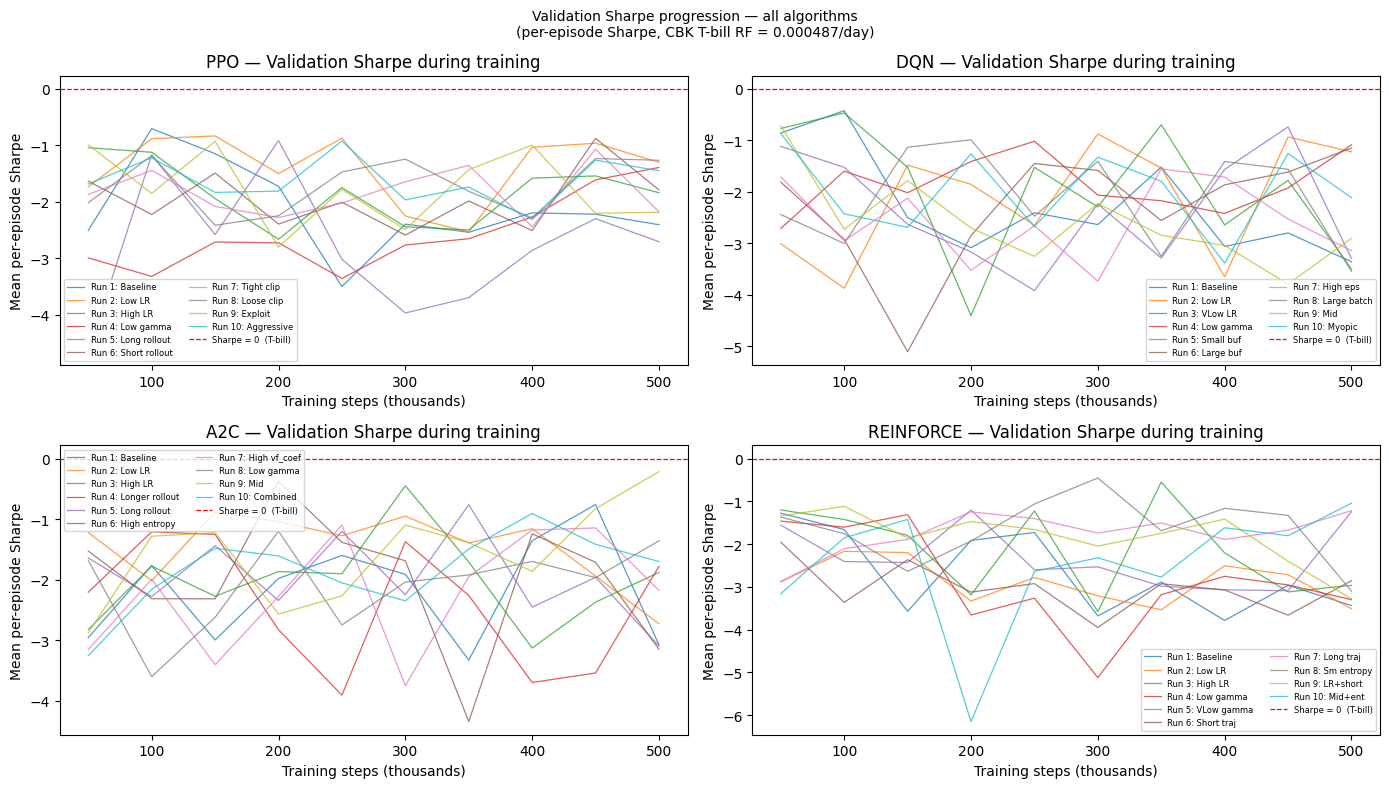

Saved: plots/sharpe_training_progression.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
algo_data = [
    ("PPO",       ppo_results),
    ("DQN",       dqn_results),
    ("A2C",       a2c_results),
    ("REINFORCE", rf_results),
]

for ax, (algo, results) in zip(axes.flatten(), algo_data):
    for r in results:
        if r.get("sharpe_history"):
            steps = [s / 1000 for s in r["sharpe_steps"]]
            ax.plot(steps, r["sharpe_history"],
                    lw=0.9, alpha=0.75,
                    label=f"Run {r['run']}: {r['note']}")
    ax.axhline(0, color="red", lw=0.9, ls="--", label="Sharpe = 0  (T-bill)")
    ax.set_title(f"{algo} — Validation Sharpe during training")
    ax.set_xlabel("Training steps (thousands)")
    ax.set_ylabel("Mean per-episode Sharpe")
    ax.legend(fontsize=6, ncol=2)

plt.suptitle(
    "Validation Sharpe progression — all algorithms\n"
    "(per-episode Sharpe, CBK T-bill RF = 0.000487/day)",
    fontsize=10
)
plt.tight_layout()
plt.savefig("plots/sharpe_training_progression.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: plots/sharpe_training_progression.png")

## Plot 2 — Episode reward learning curves

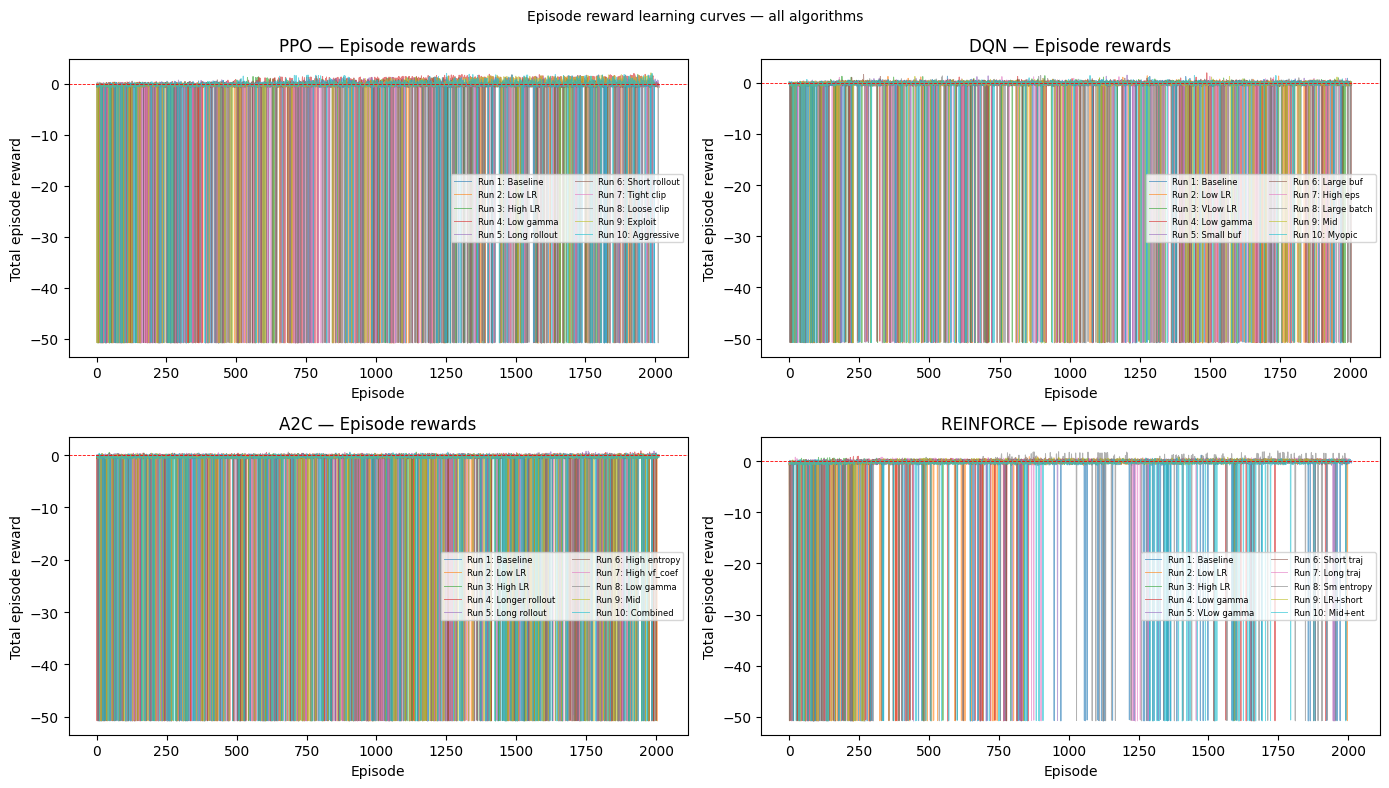

Saved: plots/reward_learning_curves.png

Training complete. Open evaluation/03_backtest.ipynb next.


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, (algo, results) in zip(axes.flatten(), algo_data):
    for r in results:
        if r.get("episode_rewards"):
            ax.plot(r["episode_rewards"], lw=0.7, alpha=0.6,
                    label=f"Run {r['run']}: {r['note']}")
    ax.axhline(0, color="red", lw=0.6, ls="--")
    ax.set_title(f"{algo} — Episode rewards")
    ax.set_xlabel("Episode")
    ax.set_ylabel("Total episode reward")
    ax.legend(fontsize=6, ncol=2)

plt.suptitle("Episode reward learning curves — all algorithms", fontsize=10)
plt.tight_layout()
plt.savefig("plots/reward_learning_curves.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: plots/reward_learning_curves.png")
print("\nTraining complete. Open evaluation/03_backtest.ipynb next.")

In [ ]:
import json, os

# Save full results from the in-memory variables that still exist
# from the training session — no retraining needed

os.makedirs("models/ppo",       exist_ok=True)
os.makedirs("models/dqn",       exist_ok=True)
os.makedirs("models/a2c",       exist_ok=True)
os.makedirs("models/reinforce", exist_ok=True)

with open("models/ppo/ppo_results_full.json", "w") as f:
    json.dump(ppo_results, f, indent=2)
print(f"PPO saved — {len(ppo_results)} runs, "
      f"episode_rewards={len(ppo_results[0].get('episode_rewards',[]))} values, "
      f"sharpe_history={len(ppo_results[0].get('sharpe_history',[]))} values")

with open("models/dqn/dqn_results_full.json", "w") as f:
    json.dump(dqn_results, f, indent=2)
print(f"DQN saved — {len(dqn_results)} runs, "
      f"episode_rewards={len(dqn_results[0].get('episode_rewards',[]))} values, "
      f"sharpe_history={len(dqn_results[0].get('sharpe_history',[]))} values")

with open("models/a2c/a2c_results_full.json", "w") as f:
    json.dump(a2c_results, f, indent=2)
print(f"A2C saved — {len(a2c_results)} runs, "
      f"episode_rewards={len(a2c_results[0].get('episode_rewards',[]))} values, "
      f"sharpe_history={len(a2c_results[0].get('sharpe_history',[]))} values")

with open("models/reinforce/reinforce_results_full.json", "w") as f:
    json.dump(rf_results, f, indent=2)
print(f"REINFORCE saved — {len(rf_results)} runs, "
      f"episode_rewards={len(rf_results[0].get('episode_rewards',[]))} values, "
      f"sharpe_history={len(rf_results[0].get('sharpe_history',[]))} values")

print("\nAll full results saved. Now run the load_results fix and plotting cells.")

PPO saved — 10 runs, episode_rewards=2009 values, sharpe_history=10 values
DQN saved — 10 runs, episode_rewards=2000 values, sharpe_history=10 values
A2C saved — 10 runs, episode_rewards=2005 values, sharpe_history=10 values
REINFORCE saved — 10 runs, episode_rewards=2014 values, sharpe_history=10 values

All full results saved. Now run the load_results fix and plotting cells.


In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

#  Load saved results 
def load_results(algo):
    full_path = f"models/{algo}/{algo}_results_full.json"
    slim_path = f"models/{algo}/{algo}_results.json"

    if Path(full_path).exists():
        with open(full_path) as f:
            results = json.load(f)
        r0 = results[0]
        has_r = len(r0.get("episode_rewards", [])) > 0
        has_s = len(r0.get("sharpe_history",  [])) > 0
        print(f"  {algo}: full results loaded  "
              f"episode_rewards={has_r}  sharpe_history={has_s}")
        return results
    elif Path(slim_path).exists():
        with open(slim_path) as f:
            results = json.load(f)
        print(f"  {algo}: slim results loaded — plots will show No data")
        return results
    else:
        print(f"  {algo}: no results file found")
        return None
def smooth(values, window=5):
    """Simple moving average to reduce noise in reward curves."""
    if len(values) < window:
        return values
    result = []
    for i in range(len(values)):
        start = max(0, i - window + 1)
        result.append(np.mean(values[start:i+1]))
    return result

ALGOS = ["ppo", "dqn", "a2c", "reinforce"]
all_results = {a: load_results(a) for a in ALGOS}
all_results = {a: r for a, r in all_results.items() if r is not None}
print(f"Loaded results for: {list(all_results.keys())}")

  ppo: full results loaded  episode_rewards=True  sharpe_history=True
  dqn: full results loaded  episode_rewards=True  sharpe_history=True
  a2c: full results loaded  episode_rewards=True  sharpe_history=True
  reinforce: full results loaded  episode_rewards=True  sharpe_history=True
Loaded results for: ['ppo', 'dqn', 'a2c', 'reinforce']


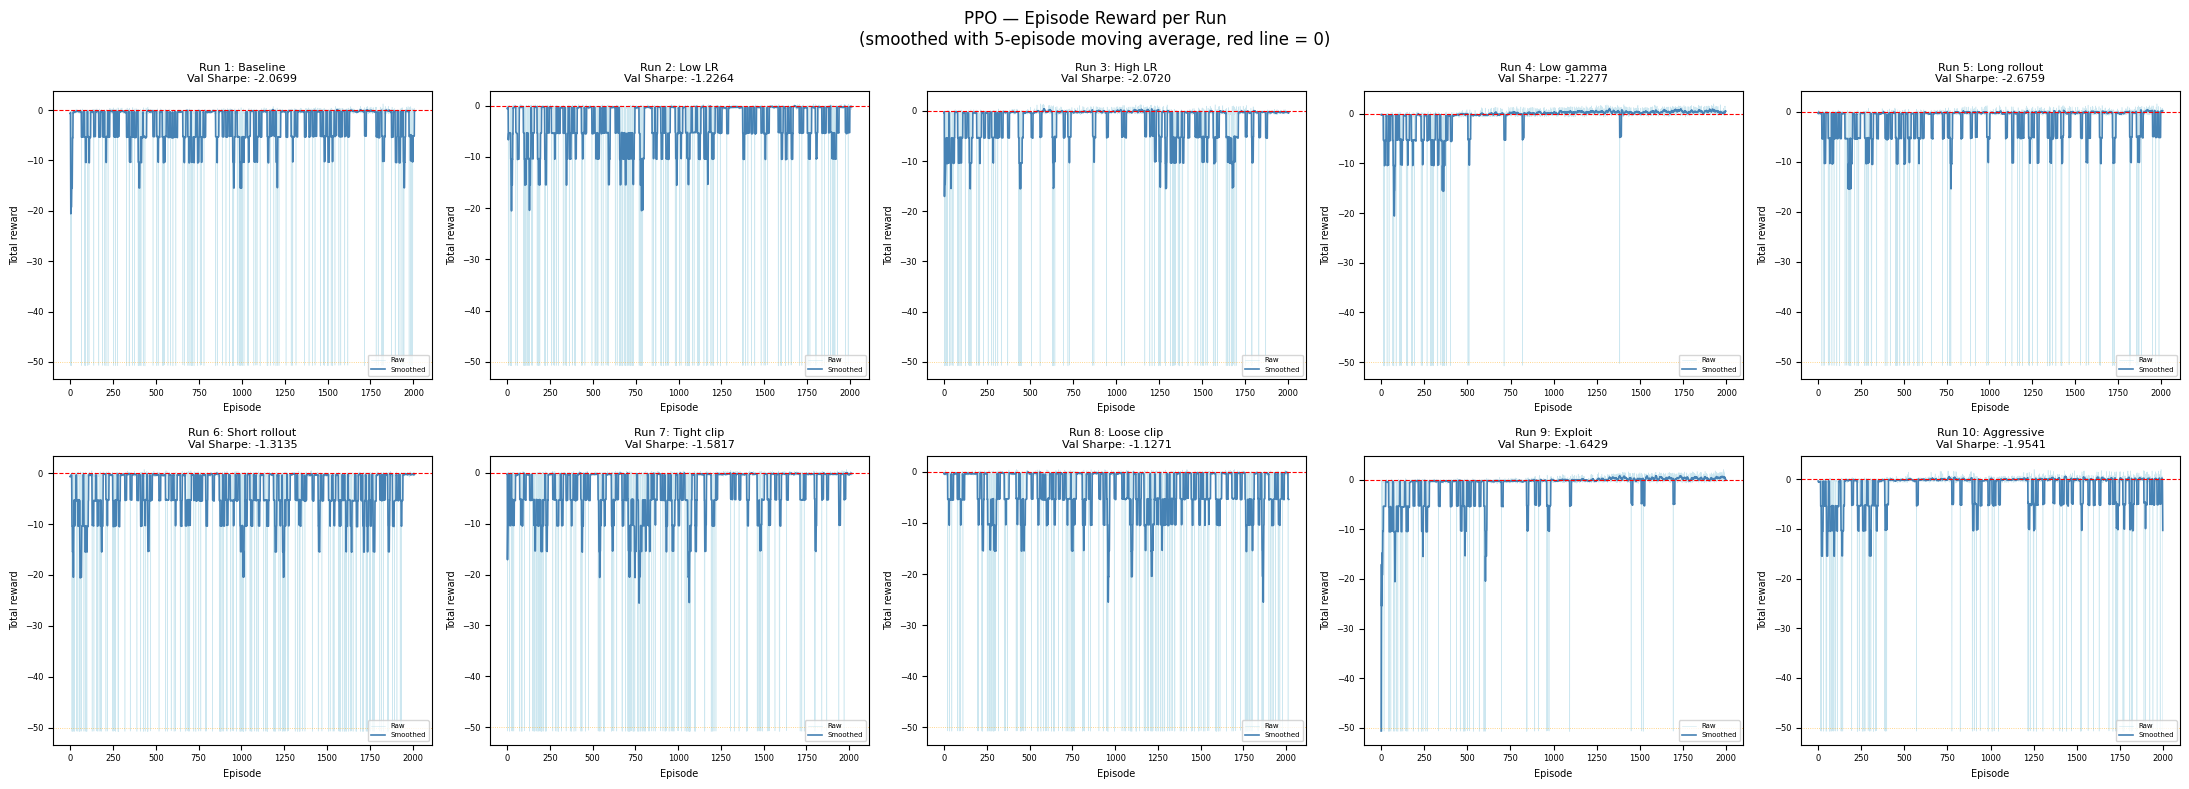

Saved: plots/ppo_reward_per_run.png


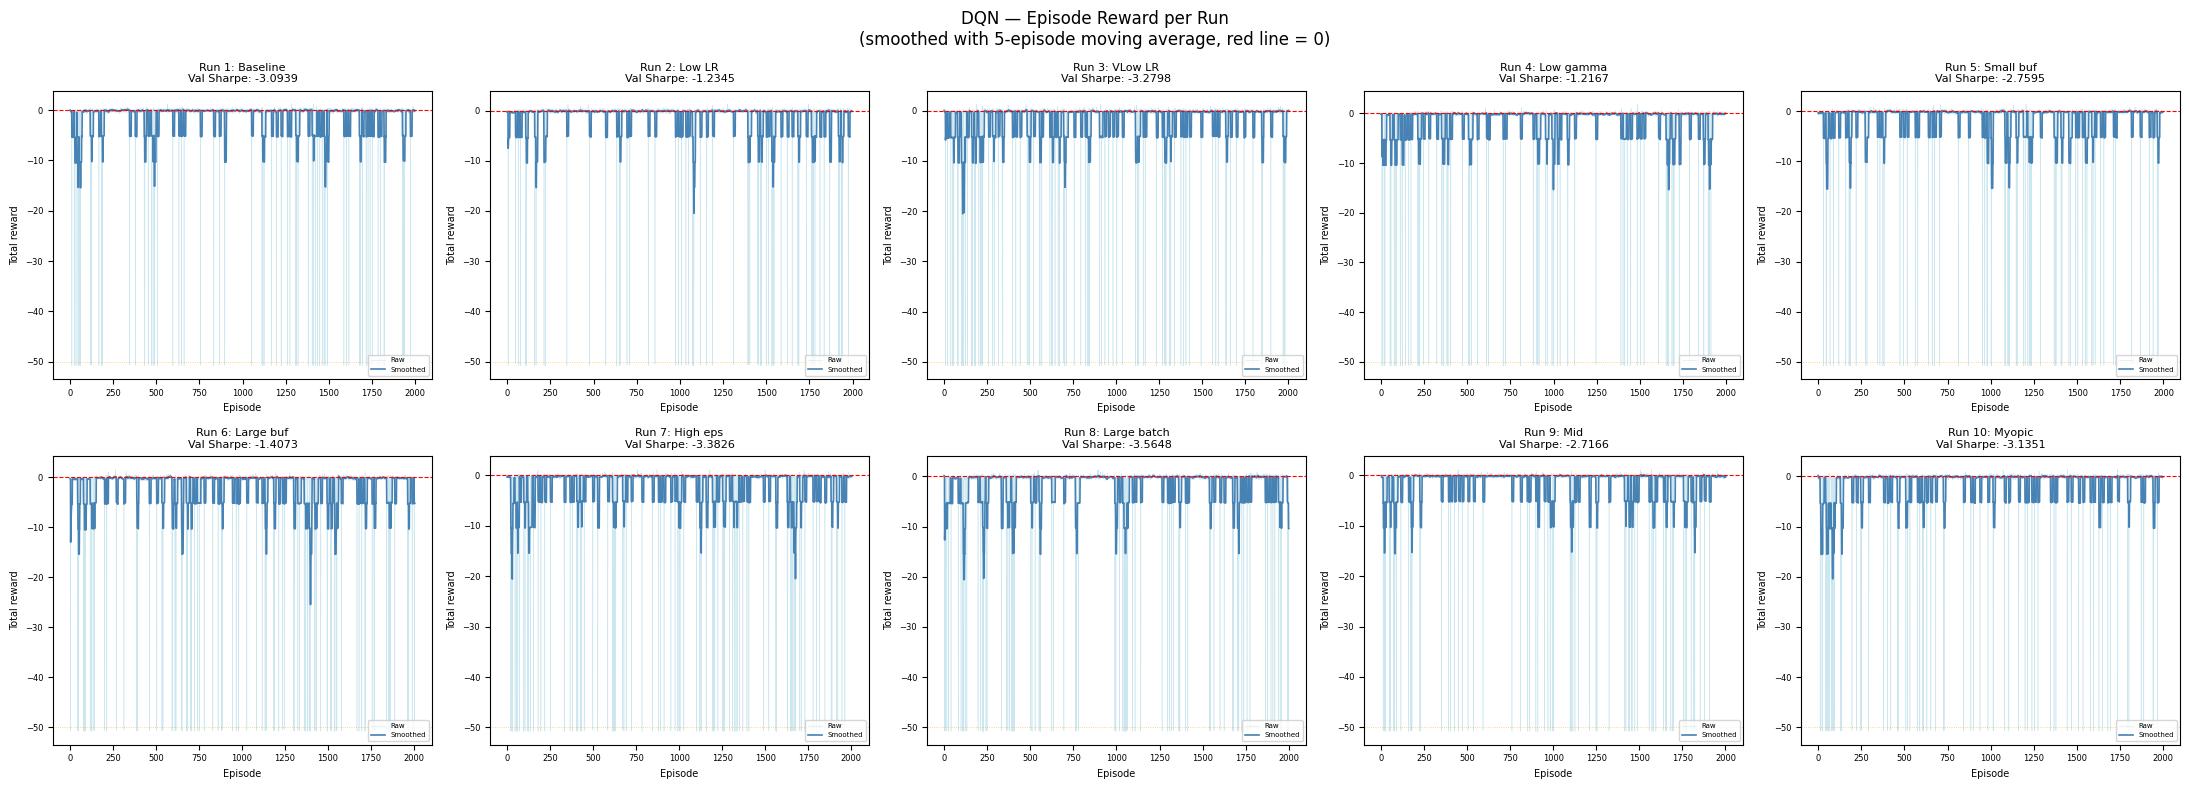

Saved: plots/dqn_reward_per_run.png


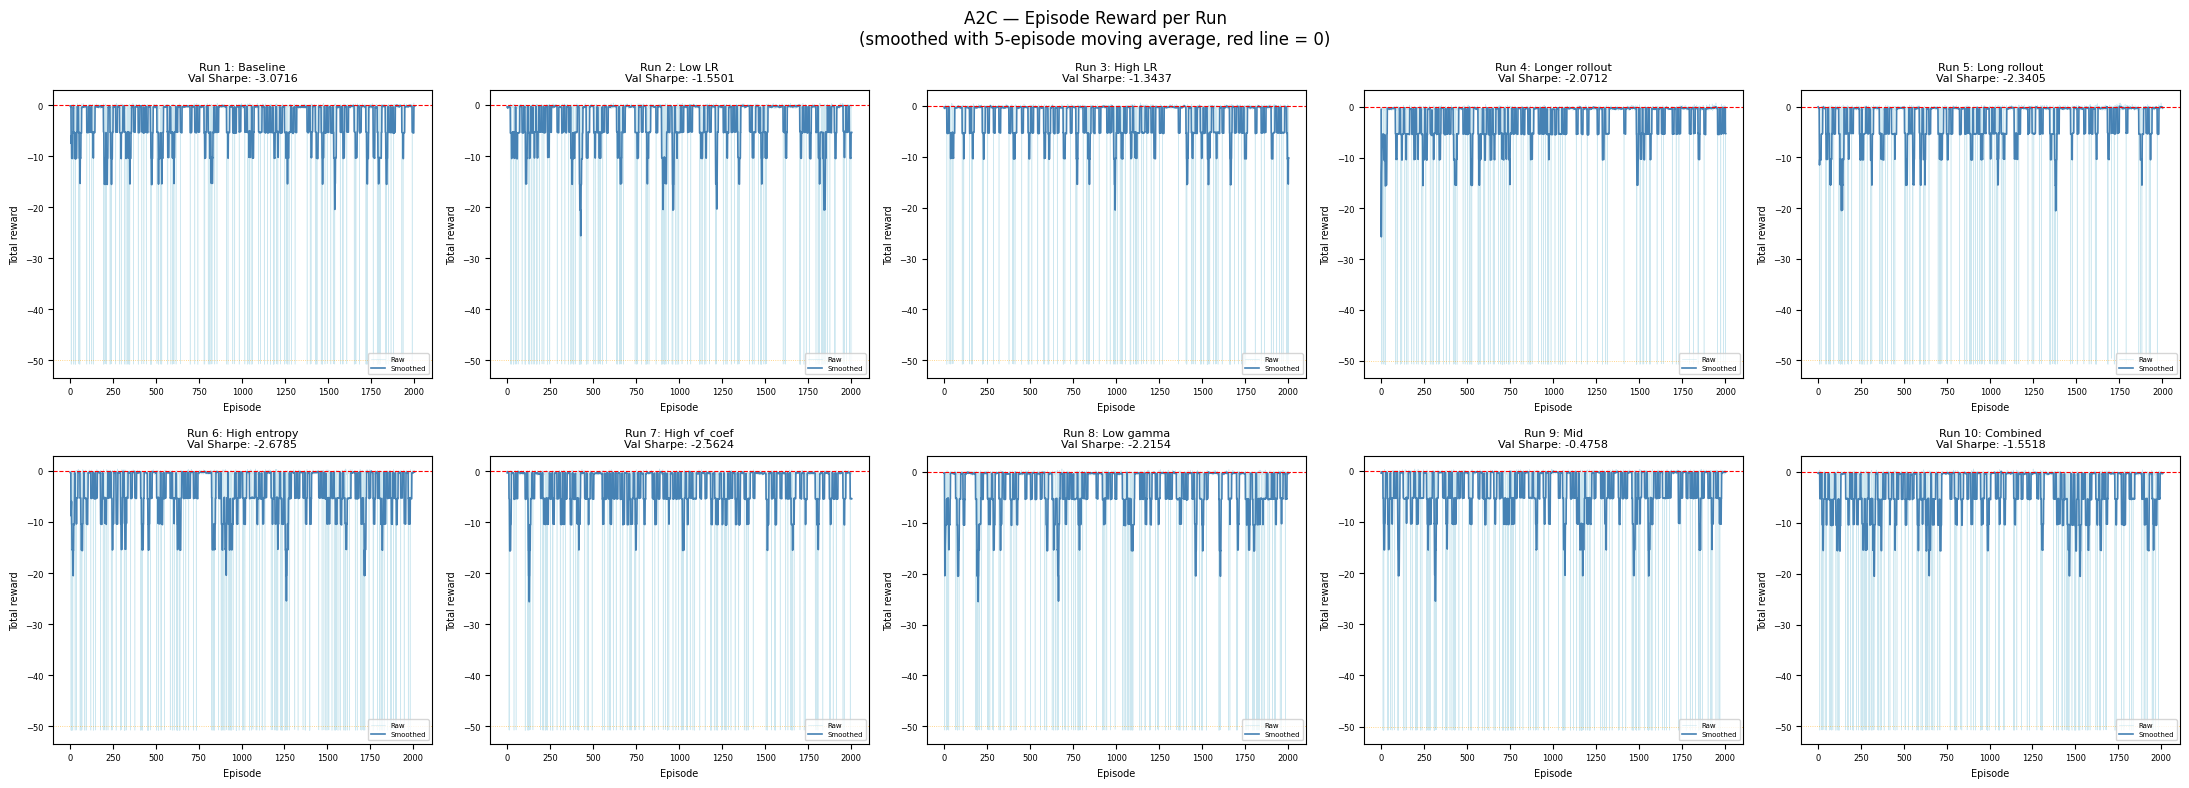

Saved: plots/a2c_reward_per_run.png


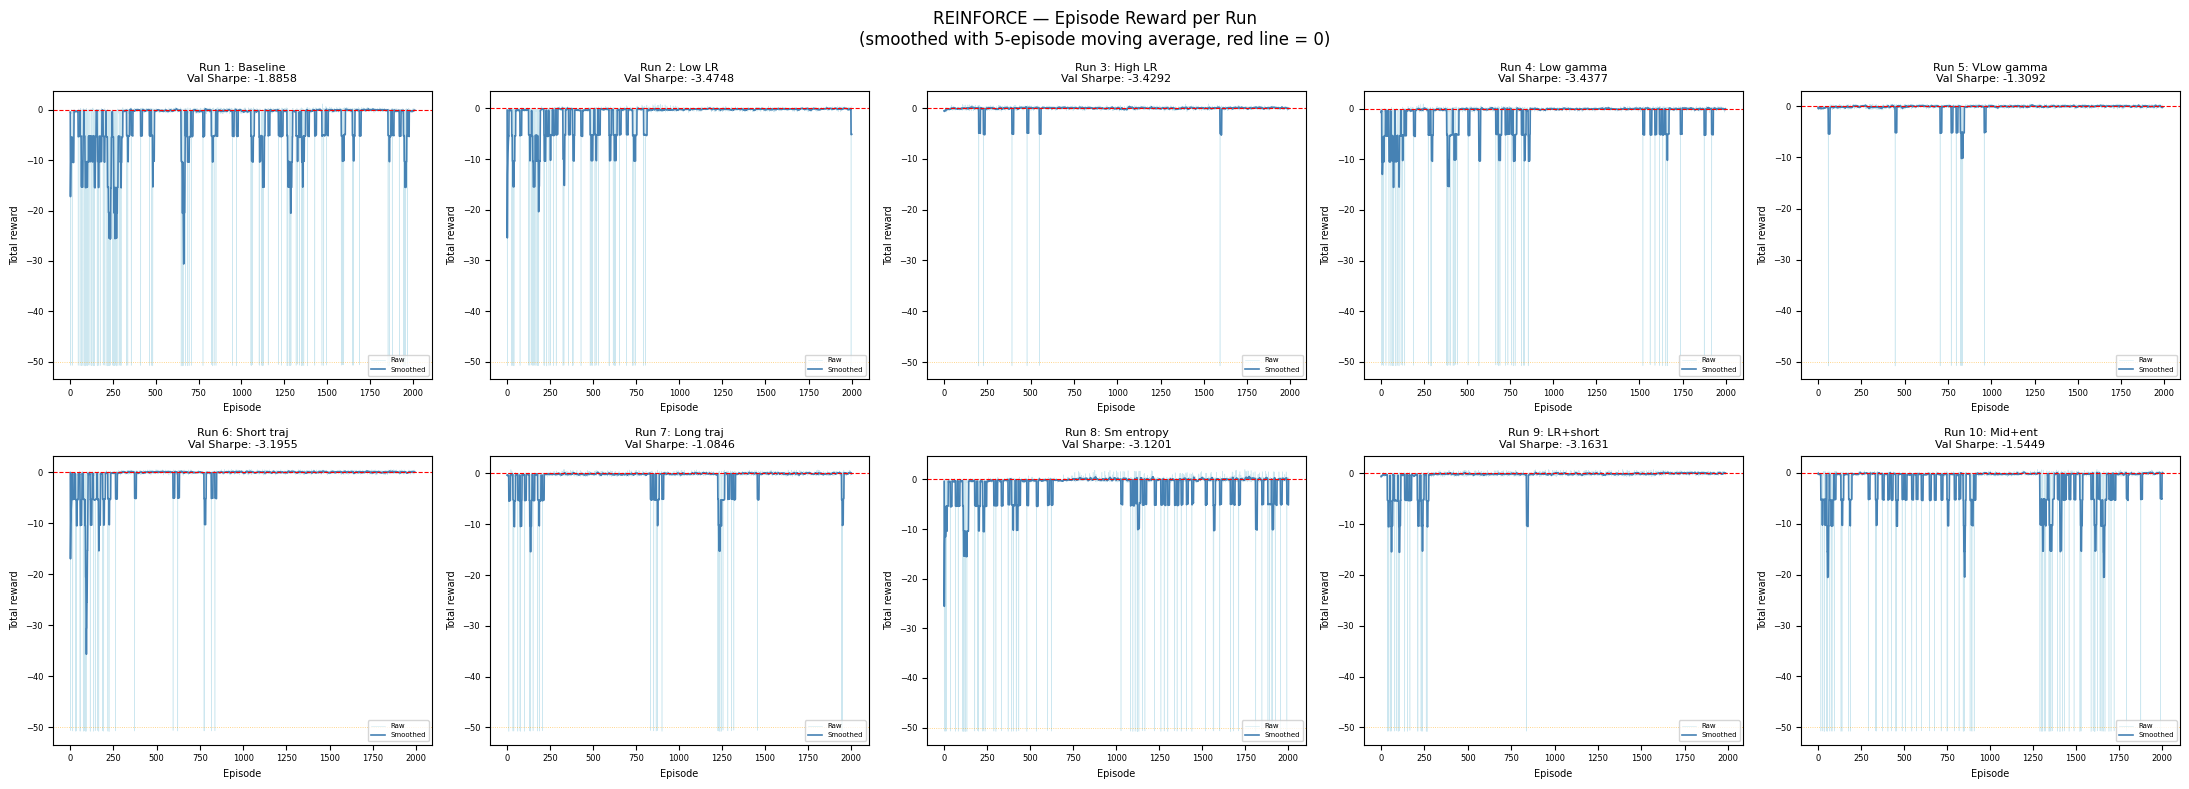

Saved: plots/reinforce_reward_per_run.png


In [ ]:
# ── Plot 1: Individual reward curves — one subplot per run ────────────────────
for algo, results in all_results.items():
    fig, axes = plt.subplots(2, 5, figsize=(22, 8))
    axes = axes.flatten()
    fig.suptitle(
        f"{algo.upper()} — Episode Reward per Run\n"
        f"(smoothed with 5-episode moving average, red line = 0)",
        fontsize=12
    )

    for i, r in enumerate(results):
        ax  = axes[i]
        raw = r.get("episode_rewards", [])

        if raw:
            ax.plot(raw, color="lightblue", lw=0.4, alpha=0.6, label="Raw")
            ax.plot(smooth(raw, window=10), color="steelblue", lw=1.2, label="Smoothed")
        else:
            ax.text(0.5, 0.5, "No data", ha="center", va="center",
                    transform=ax.transAxes, fontsize=10)

        ax.axhline(0, color="red", lw=0.8, ls="--")
        ax.axhline(-50, color="orange", lw=0.6, ls=":", alpha=0.6)
        ax.set_title(
            f"Run {r['run']}: {r.get('note','')}\n"
            f"Val Sharpe: {r.get('val_sharpe', 'N/A'):+.4f}",
            fontsize=8
        )
        ax.set_xlabel("Episode", fontsize=7)
        ax.set_ylabel("Total reward", fontsize=7)
        ax.tick_params(labelsize=6)
        ax.legend(fontsize=5, loc="lower right")

    plt.tight_layout()
    path = f"plots/{algo}_reward_per_run.png"
    plt.savefig(path, dpi=130, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path}")

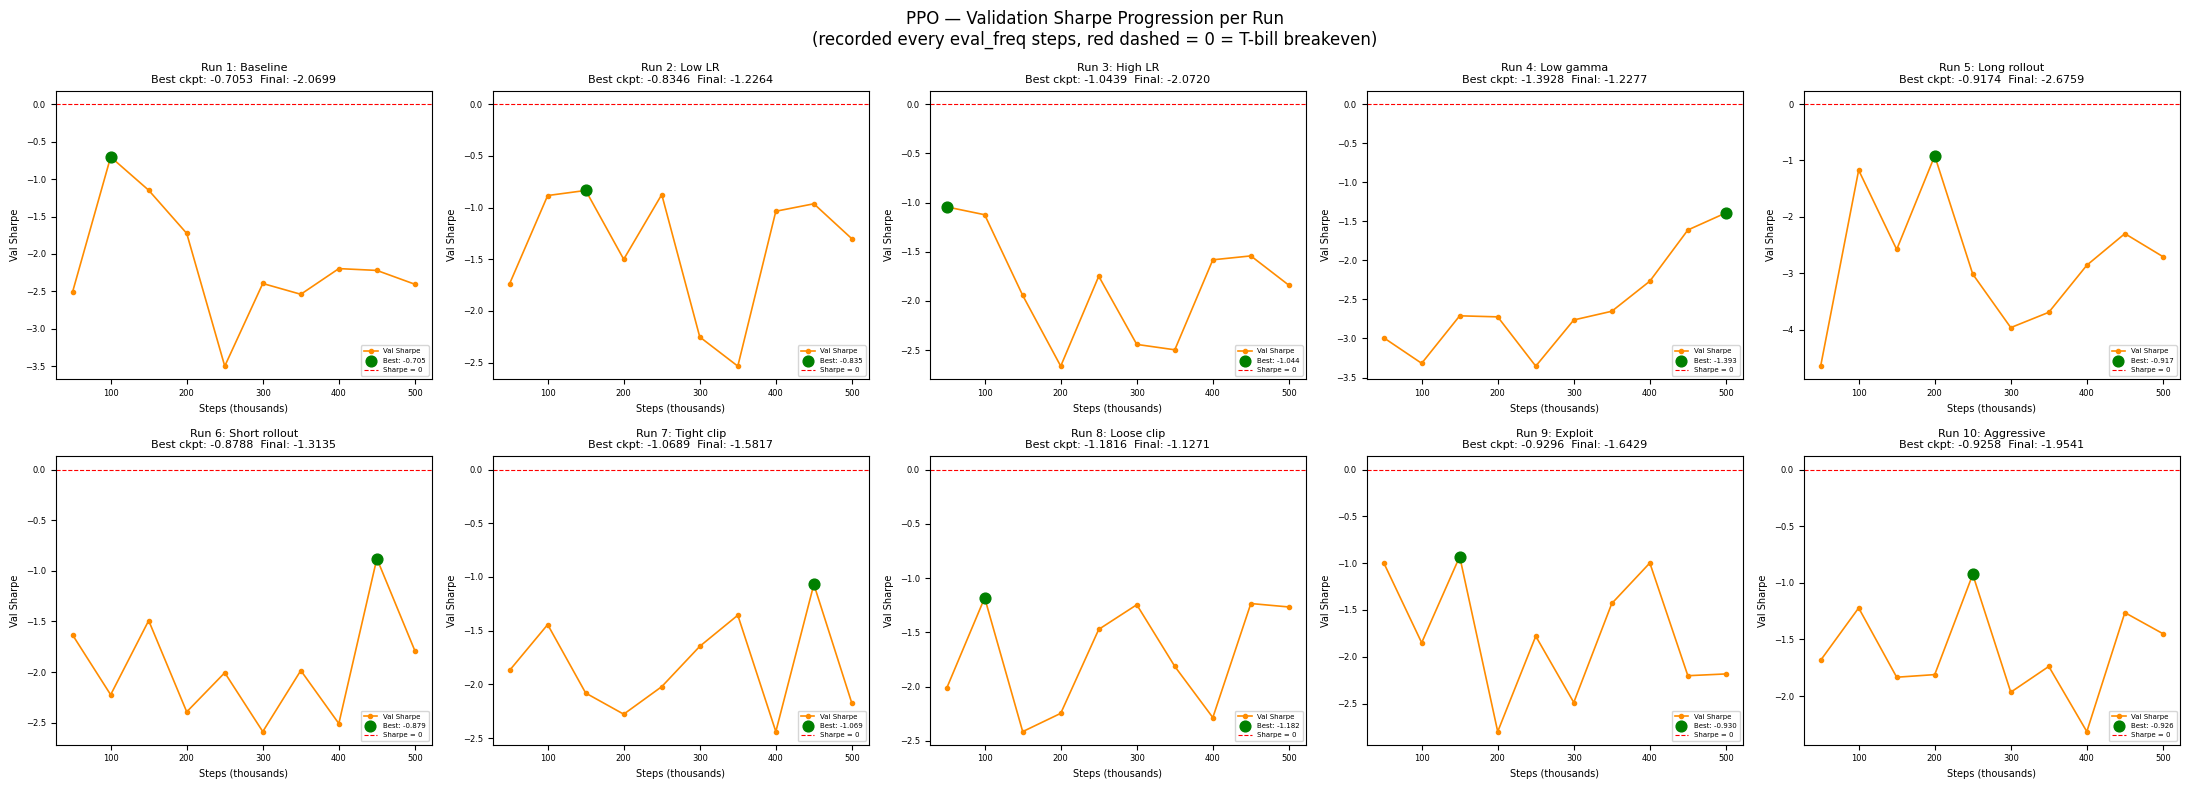

Saved: plots/ppo_sharpe_per_run.png


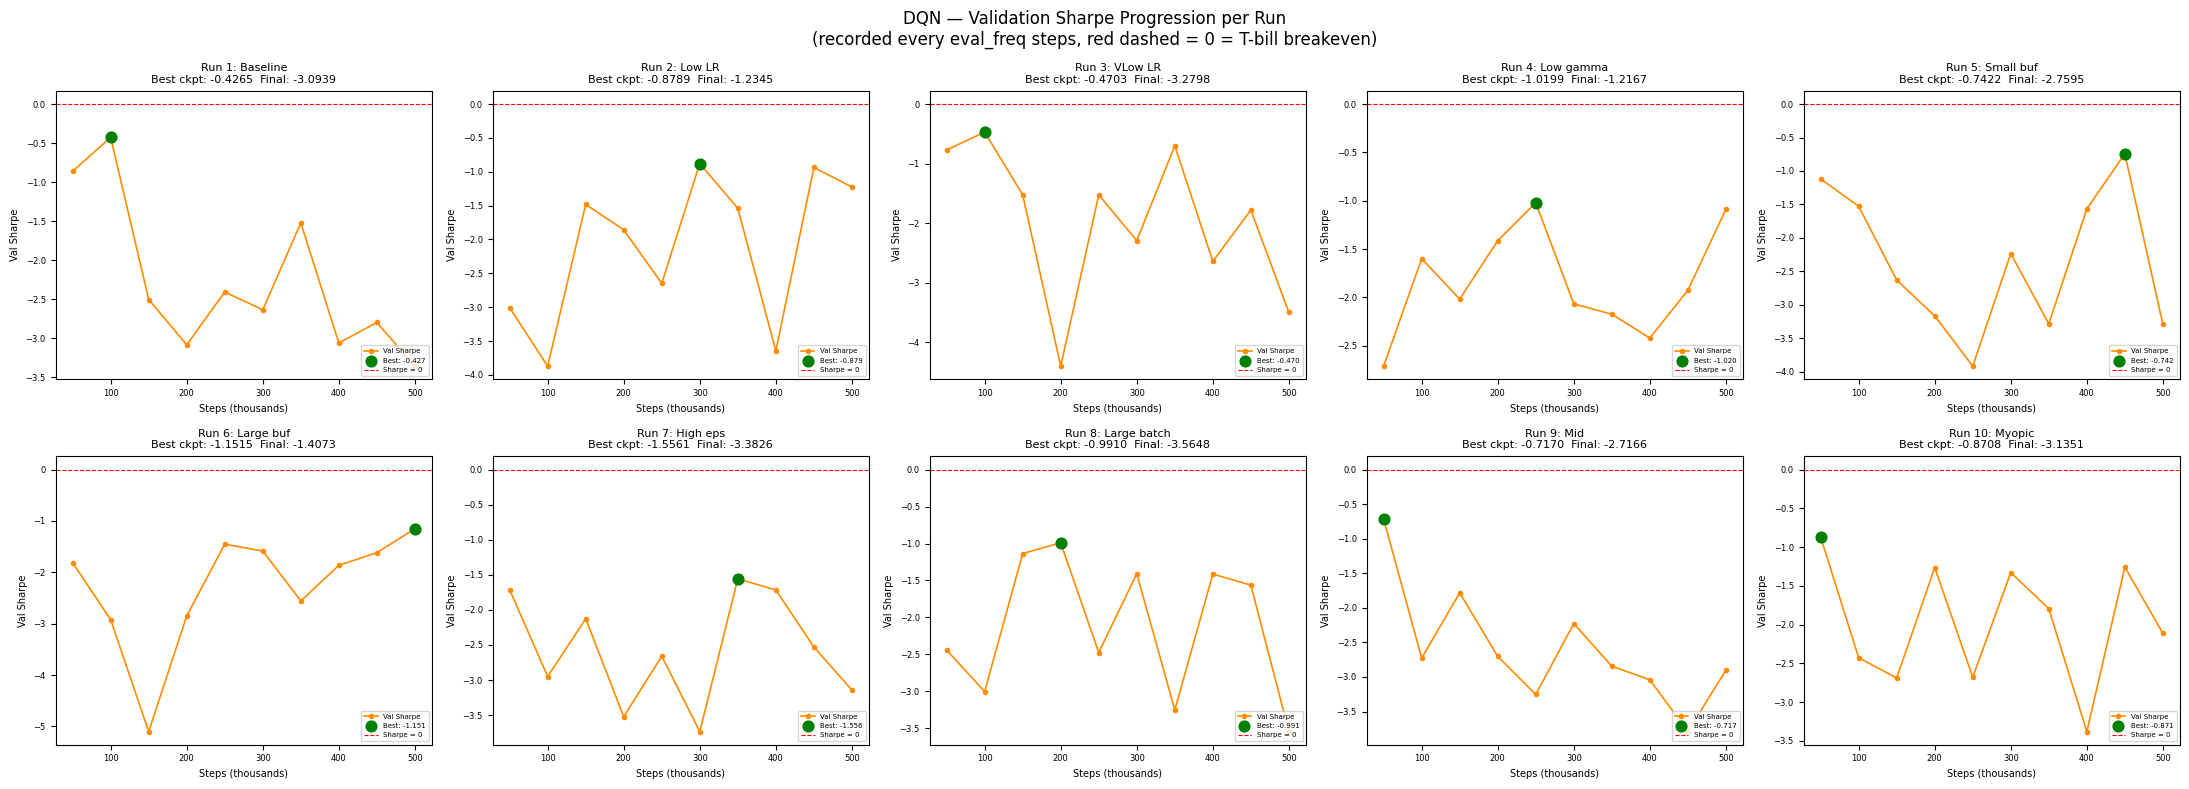

Saved: plots/dqn_sharpe_per_run.png


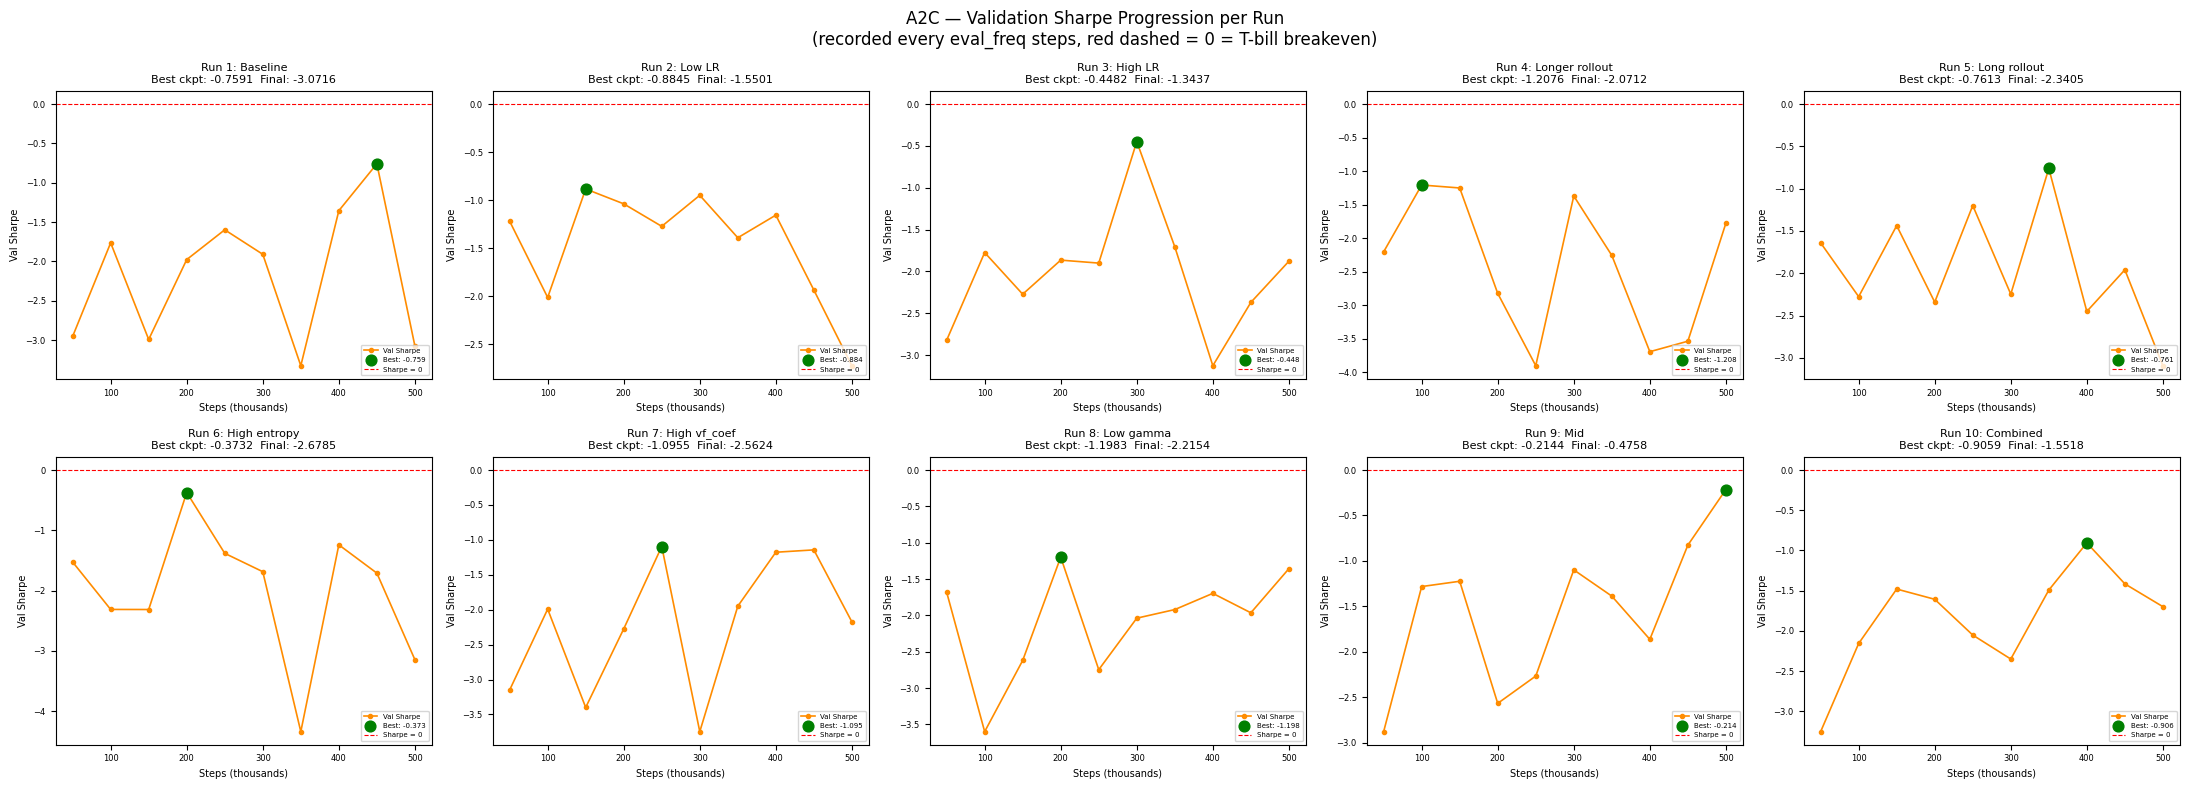

Saved: plots/a2c_sharpe_per_run.png


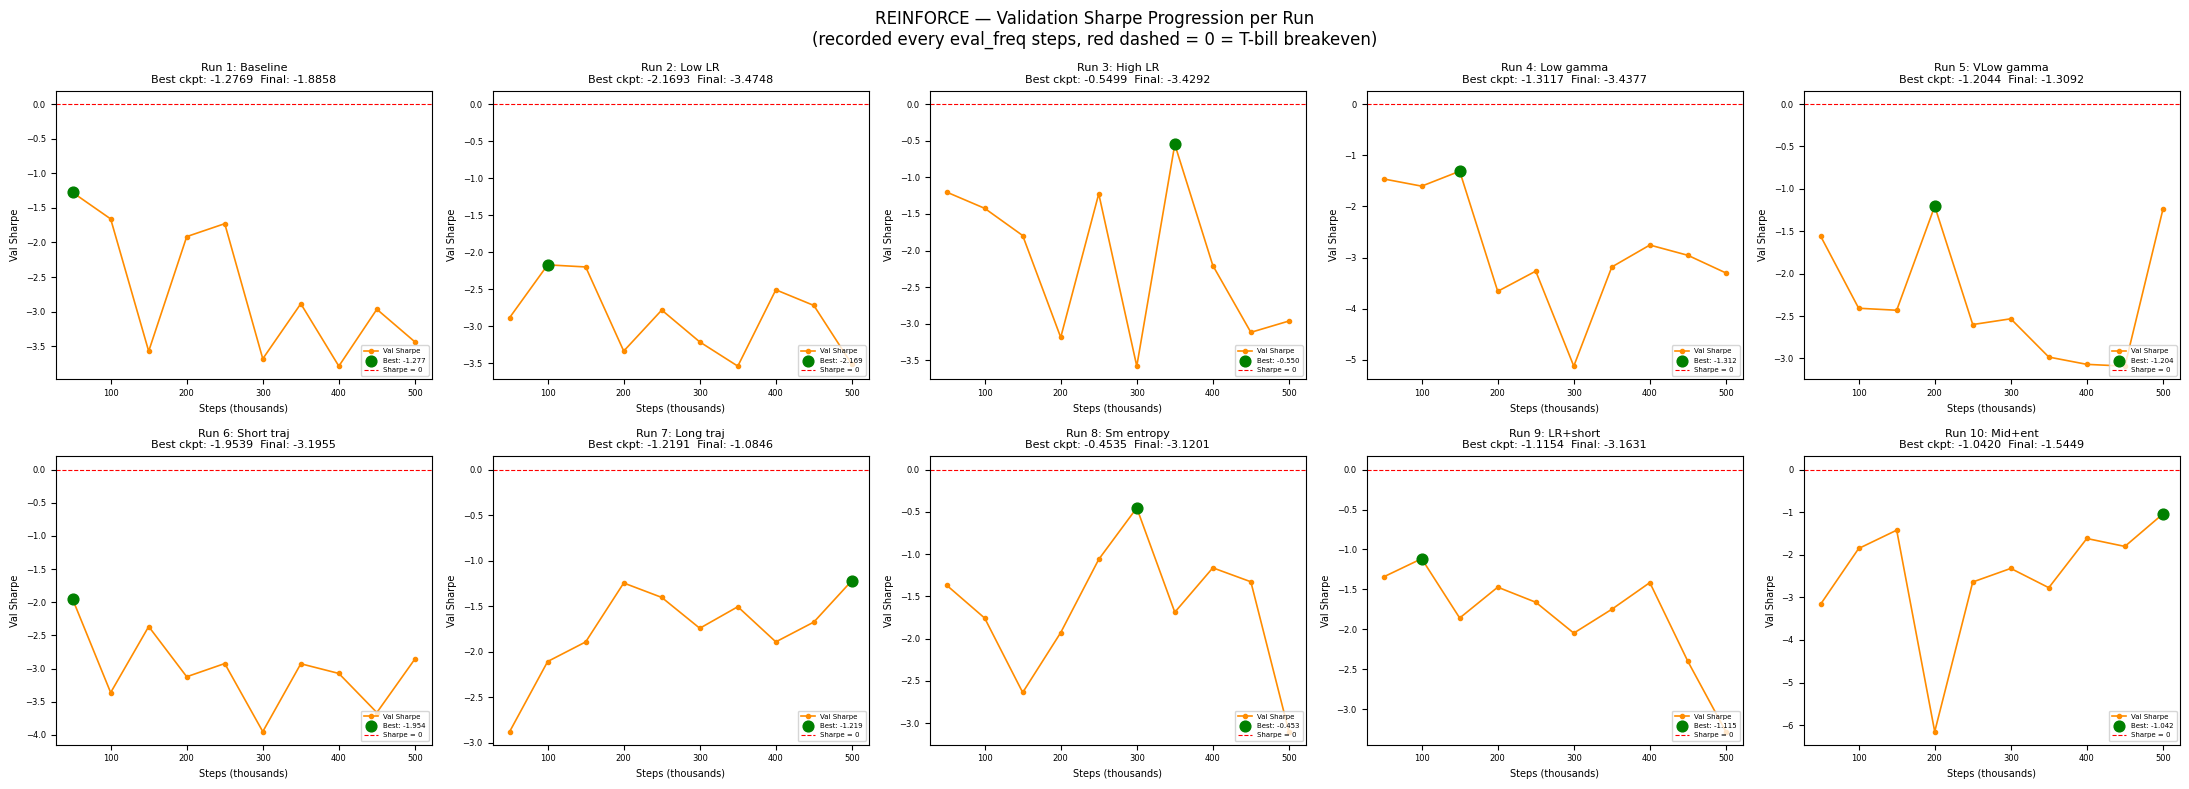

Saved: plots/reinforce_sharpe_per_run.png


In [ ]:
# ── Plot 2: Sharpe progression — one subplot per run ─────────────────────────
for algo, results in all_results.items():
    fig, axes = plt.subplots(2, 5, figsize=(22, 8))
    axes = axes.flatten()
    fig.suptitle(
        f"{algo.upper()} — Validation Sharpe Progression per Run\n"
        f"(recorded every eval_freq steps, red dashed = 0 = T-bill breakeven)",
        fontsize=12
    )

    for i, r in enumerate(results):
        ax   = axes[i]
        sh   = r.get("sharpe_history", [])
        steps= r.get("sharpe_steps",   [])

        if sh and steps:
            steps_k = [s / 1000 for s in steps]
            ax.plot(steps_k, sh, color="darkorange", lw=1.2, marker="o",
                    markersize=3, label="Val Sharpe")
            # Mark the best checkpoint
            best_idx = int(np.argmax(sh))
            ax.scatter(steps_k[best_idx], sh[best_idx],
                       color="green", s=60, zorder=5,
                       label=f"Best: {sh[best_idx]:+.3f}")
        else:
            ax.text(0.5, 0.5, "No data", ha="center", va="center",
                    transform=ax.transAxes, fontsize=10)

        ax.axhline(0, color="red", lw=0.8, ls="--", label="Sharpe = 0")
        ax.set_title(
            f"Run {r['run']}: {r.get('note','')}\n"
            f"Best ckpt: {r.get('best_ckpt_sharpe', 'N/A'):+.4f}  "
            f"Final: {r.get('val_sharpe', 'N/A'):+.4f}",
            fontsize=8
        )
        ax.set_xlabel("Steps (thousands)", fontsize=7)
        ax.set_ylabel("Val Sharpe", fontsize=7)
        ax.tick_params(labelsize=6)
        ax.legend(fontsize=5, loc="lower right")

    plt.tight_layout()
    path = f"plots/{algo}_sharpe_per_run.png"
    plt.savefig(path, dpi=130, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path}")

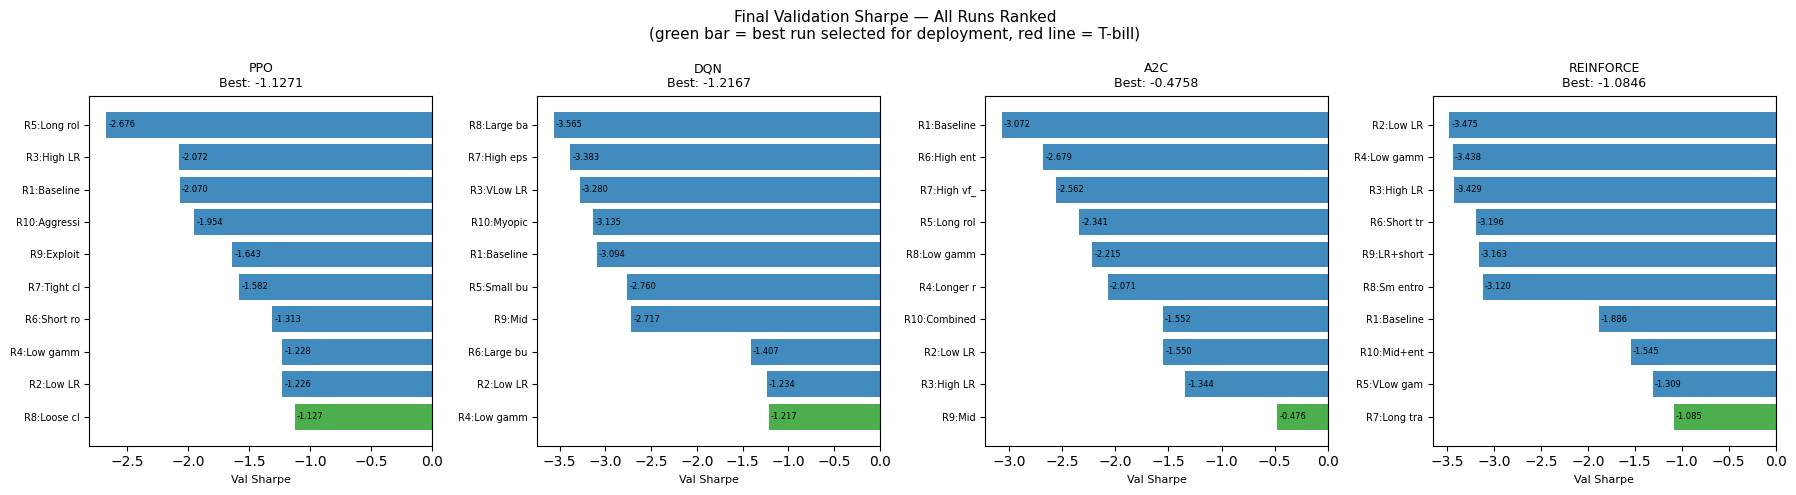

Saved: plots/algorithm_ranking.png


In [ ]:
# ── Plot 3: Algorithm ranking by final validation Sharpe ──────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle(
    "Final Validation Sharpe — All Runs Ranked\n"
    "(green bar = best run selected for deployment, red line = T-bill)",
    fontsize=11
)

for ax, (algo, results) in zip(axes, all_results.items()):
    runs   = [r["run"]        for r in results]
    sharpes= [r.get("val_sharpe", -99) for r in results]
    notes  = [r.get("note","") for r in results]

    # Sort by Sharpe descending
    order  = np.argsort(sharpes)[::-1]
    s_sorted = [sharpes[i] for i in order]
    n_sorted = [f"R{runs[i]}:{notes[i][:8]}" for i in order]

    colors = ["#2ca02c" if i == 0 else "#1f77b4" for i in range(len(s_sorted))]
    bars   = ax.barh(range(len(s_sorted)), s_sorted, color=colors, alpha=0.85)
    ax.set_yticks(range(len(s_sorted)))
    ax.set_yticklabels(n_sorted, fontsize=7)
    ax.axvline(0, color="red", lw=0.8, ls="--")
    ax.set_title(f"{algo.upper()}\nBest: {s_sorted[0]:+.4f}", fontsize=9)
    ax.set_xlabel("Val Sharpe", fontsize=8)

    # Label bars
    for bar, val in zip(bars, s_sorted):
        ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                f"{val:+.3f}", va="center", fontsize=6)

plt.tight_layout()
plt.savefig("plots/algorithm_ranking.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: plots/algorithm_ranking.png")

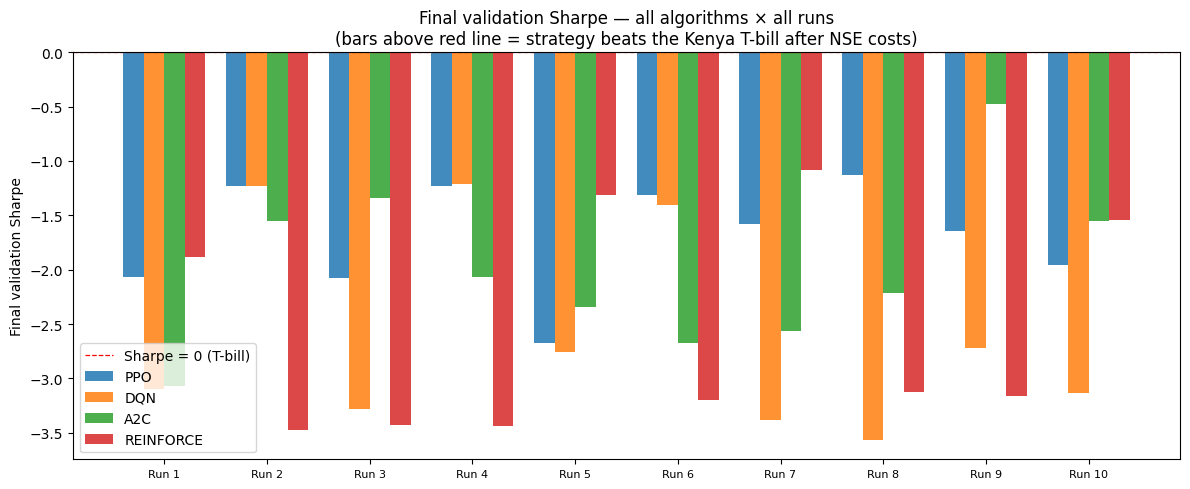

Saved: plots/all_runs_comparison.png


In [ ]:
# ── Plot 4: Cross-algorithm Sharpe comparison at end of training ──────────────
fig, ax = plt.subplots(figsize=(12, 5))

x     = np.arange(10)
width = 0.2
colors= ["#1f77b4","#ff7f0e","#2ca02c","#d62728"]

for i, (algo, results) in enumerate(all_results.items()):
    sharpes = [r.get("val_sharpe", -99) for r in sorted(results, key=lambda r: r["run"])]
    ax.bar(x + i * width, sharpes, width, label=algo.upper(),
           color=colors[i], alpha=0.85)

ax.axhline(0, color="red", lw=0.9, ls="--", label="Sharpe = 0 (T-bill)")
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([f"Run {i+1}" for i in range(10)], fontsize=8)
ax.set_ylabel("Final validation Sharpe")
ax.set_title(
    "Final validation Sharpe — all algorithms × all runs\n"
    "(bars above red line = strategy beats the Kenya T-bill after NSE costs)"
)
ax.legend()
plt.tight_layout()
plt.savefig("plots/all_runs_comparison.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: plots/all_runs_comparison.png")